In [ ]:
#Step 1: Import the necessary libraries
import pandas as pd #For data manipulation and analysis(dataframes)
import numpy as np #For numerical operations, especially with arrays
from sklearn.model_selection import train_test_split #To split the data into training and testing sets.
from sklearn.preprocessing import StandardScaler, LabelEncoder #StandardScaleer for feature scaling, Label Encoder for categorical encoding
from sklearn.ensemble import RandomForestClassifier #ML model used for classification --> Random Forest (RF)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt #For plotting and creating visualizations
import seaborn as sns #For enhanced visualizations


In [ ]:
#Step 2: Load the dataset
#url = "https://www.kaggle.com/datasets/kanyianalyst/car-evaluation-dataset?select=car+evaluation_with.csv"

headers = ['buying', 'maintenance', 'doors', 'persons', 'lug_boot', 'safety', 'class'] #Define features, header not in original dataset
car_df = pd.read_csv("car_evaluation.csv", names=headers) #Load the dataset into a pandas DataFrame
car_df.head()

,buying,maintenance,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [8]:
#Check for missing values and data types
print(car_df.isnull().sum())
print(car_df.dtypes)

buying         0
maintenance    0
doors          0
persons        0
lug_boot       0
safety         0
class          0
dtype: int64
buying           str
maintenance      str
doors          int64
persons        int64
lug_boot         str
safety           str
class            str
dtype: object


In [9]:
#Step 3: Data Preprocessing

features = ['buying', 'maintenance', 'doors', 'persons', 'lug_boot', 'safety'] #Features for training the model
X = car_df[features].copy() #Create feature matrix X with selcted coumns and create a copy to avoid SettingWithCopyWarning

#No missing values to handle

#Encode categorical features into a numerical format
X['buying'] = LabelEncoder().fit_transform(X['buying'])
X['maintenance'] = LabelEncoder().fit_transform(X['maintenance'])
X['lug_boot'] = LabelEncoder().fit_transform(X['lug_boot'])
X['safety'] = LabelEncoder().fit_transform(X['safety'])

#Define the target variable (waht we want to predict)
y = car_df['class'] # 0 - 3 (acc, good, unacc, vgood)

In [10]:
#Step 4: Split the dataset into training and testing sets.

#80/20 split for training and testing
#random state for reproducibility
#stratify=y to maintain class distribution in both sets

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [11]:
#Step 5: Scale the features useing StandardScaler
scaler = StandardScaler() #Initialize the scaler
X_train= scaler.fit_transform(X_train) #Fit scaler on training data and transform it
X_test = scaler.transform(X_test) #Transform the test data using the same scaler fitted on training data

In [12]:
#Step 6: Train the RandomForest Classifier

clf = RandomForestClassifier(n_estimators=100, random_state=42) #Initialize the model with 100 trees and a random state for reproducibility
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
#Step 7: Make Prediction on the test set
y_pred = clf.predict(X_test)

Accuracy: 0.9855491329479769
Classification Report: 
               precision    recall  f1-score   support

         acc       0.96      0.97      0.97        77
        good       1.00      1.00      1.00        14
       unacc       0.99      0.99      0.99       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.99      0.97      0.98       346
weighted avg       0.99      0.99      0.99       346



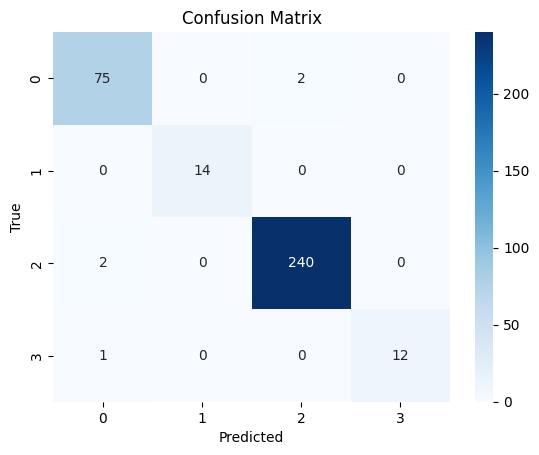

In [15]:
#Step 8: Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred)) #Print Overall accuracy of the model
print("Classification Report: \n", classification_report(y_test, y_pred)) #Print precision, recall, f1-score for each class

#Generate and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

Decision Tree Accuracy: 0.9884393063583815
Decision Tree Classification Report: 
               precision    recall  f1-score   support

         acc       0.96      0.99      0.97        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



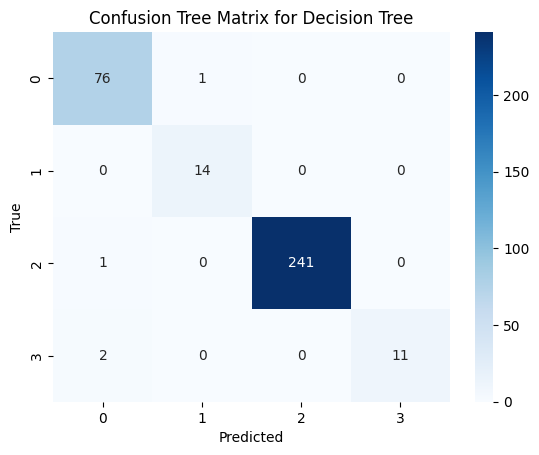

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report: \n", classification_report(y_test, y_pred_dt))

#Generate and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Tree Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [18]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Random Forest Accuracy: 0.9855491329479769
Decision Tree Accuracy: 0.9884393063583815
